# PROTAC-PEDIA Data Curation

## Setup and Imports

In [28]:
from IPython.display import display_html
# from IPython.core.interactiveshell import InteractiveShell
# InteractiveShell.ast_node_interactivity = 'all'

import collections
import itertools
import re
import gc
import math
import numpy as np
import pandas as pd
import pickle
import requests as r
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import os

import typing
from typing import Mapping, Literal, Callable, List, ClassVar, Any

from uuid import uuid4
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs, MACCSkeys
from datetime import date
from scipy.sparse import csr_matrix, vstack

import sklearn
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn import preprocessing
from sklearn import metrics
from sklearn.metrics import classification_report, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import class_weight

pd.set_option('display.max_columns', 1000, 'display.width', 2000, 'display.max_colwidth', 100)

In [29]:
data_dir = os.path.join(os.getcwd(), '..', 'data')
src_dir = os.path.join(os.getcwd(), '..', 'src')
fig_dir = os.path.join(data_dir, 'figures')
checkpoint_dir = os.path.join(os.getcwd(), '..', 'checkpoints')
dirs_to_make = [
    src_dir,
    data_dir,
    os.path.join(data_dir, 'processed'),
    os.path.join(data_dir, 'smiles_in_smiles_out'),
    os.path.join(data_dir, 'smiles_in_selfies_out'),
    os.path.join(data_dir, 'selfies_in_selfies_out'),
    
    os.path.join(data_dir, 'smiles_in_smiles_out_randorder'),
    os.path.join(data_dir, 'smiles_in_selfies_out_randorder'),
    os.path.join(data_dir, 'selfies_in_selfies_out_randorder'),
    
    # os.path.join(data_dir, 'raw'),
    # os.path.join(data_dir, 'train'),
    # os.path.join(data_dir, 'val'),
    # os.path.join(data_dir, 'test'),
    # fig_dir,
    # checkpoint_dir,
]
for d in dirs_to_make:
    if not os.path.exists(d):
        os.makedirs(d)

## Data Curation

In [30]:
df_file = os.path.join(data_dir, 'raw', 'protac_pedia_20220210.csv')
protac_pedia_df = pd.read_csv(df_file)
print(protac_pedia_df.head())

   PROTACDB ID                                                                                        PROTAC SMILES Active/Inactive Best PROTAC   Cells     cLogP                              Comments        Curator   Dc50     Dmax                                                             E3 Binder SMILES E3 Ligase Ec50 of Ligand Cells Ec50 of PROTAC Cells               exit_vector  Hbond acceptors  Hbond donors Ic50 of Ligand Ic50 of PROTAC Ligand Name                                                                                        Ligand SMILES          Linker Linker Type  linker_ha  linker_no  linker_rb        MW    Off Targets Reported PATENT Ligand PDB Ligand ID      Pubmed  PROTAC Name Proteomics Data Available  Secondary Pubmed    Status  Target Tested A Non Binding E3 Control Tested Competition With Ligand Tested Engagement In Cells Tested Proteaseome Inhibitor Time    TPSA
0            1  Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CC(=O)N2CCN(CC[

Canonize SMILES:

In [31]:
canonize = lambda x: Chem.MolToSmiles(Chem.MolFromSmiles(x))
protac_pedia_df['PROTAC SMILES'] = protac_pedia_df['PROTAC SMILES'].apply(canonize)

Remove stereochemistry:

In [32]:
def remove_stereochemistry(smiles):
    mol = Chem.MolFromSmiles(smiles)
    Chem.RemoveStereochemistry(mol) # NOTE: It's a void function (returns None)
    return Chem.MolToSmiles(mol)

protac_pedia_df['PROTAC SMILES_nostereo'] = protac_pedia_df['PROTAC SMILES'].apply(remove_stereochemistry)

Drop entries with no $DC_{50}$ nor $D_{max}$ values:

In [33]:
print('Total lenght:', len(protac_pedia_df))
print('Active/Inactive lenght:', len(protac_pedia_df.dropna(subset=['Active/Inactive'])))
print('No DC50 nor Dmax lenght:', len(protac_pedia_df.dropna(subset=['Dc50', 'Dmax'])))
# protac_pedia_df = protac_pedia_df.dropna(subset=['Dc50', 'Dmax'])

Total lenght: 1203
Active/Inactive lenght: 1203
No DC50 nor Dmax lenght: 164


Remove entries with no Dmax nor DC50 values (and create copies of original columns):

In [34]:
# protac_pedia_df.dropna(subset=['Dmax'], inplace=True)
# protac_pedia_df.dropna(subset=['Dc50'], inplace=True)
protac_pedia_df['Active/Inactive (Original)'] = protac_pedia_df['Active/Inactive'].copy()
protac_pedia_df['Dmax (Original)'] = protac_pedia_df['Dmax'].copy()
protac_pedia_df['Active/Inactive'] = protac_pedia_df['Active/Inactive'].replace({'Active': True, 'Inactive': False})

Clean and convert Dmax and DC50 string entries to float:

In [35]:
def clean_string(s: str) -> str:
    if 'nan' in s or 'n/a' in s or 'NaN' in s:
        return 'nan'
    tmp = re.sub(r'[<=>]', '', s) # Remove <, >, =
    tmp = re.sub(r'\(n/a\)', '0', tmp)
    tmp = re.sub(r'NaN', '0', tmp)
    tmp = re.sub(r'[\d]+[-~]', '', tmp) # Remove range, like: 100-200 -> 200
    return tmp

def deep_clean_string(s: str) -> str:
    tmp = clean_string(s)
    tmp = re.sub(r'[~<=>% ]', '', s) # Remove ~, <, >, =, % and spaces
    return tmp

def string_to_float(s: str) -> float:
    if 'nM' in s:
        tmp = s.replace('nM', '')
        tmp = float(tmp) * 1e-9
    elif 'uM' in s:
        tmp = s.replace('uM', '')
        tmp = float(tmp) * 1e-6
    else:
        tmp = float(s)
    return tmp

Add $pDC_{50}$ column:

In [36]:
protac_pedia_df['DC50'] = protac_pedia_df['Dc50'].apply(lambda s: string_to_float(deep_clean_string(str(s))))
protac_pedia_df['pDC50'] = -np.log10(protac_pedia_df['DC50'])
protac_pedia_df['pDC50']

0            NaN
1            NaN
2            NaN
3            NaN
4       7.275724
          ...   
1198         NaN
1199         NaN
1200         NaN
1201    6.698970
1202    7.522879
Name: pDC50, Length: 1203, dtype: float64

Convert $D_{max}$ range from 1-100 to 0-1:

In [37]:
protac_pedia_df['Dmax'] = protac_pedia_df['Dmax'].apply(lambda s: string_to_float(deep_clean_string(str(s)))) / 100
protac_pedia_df['Dmax']

0       NaN
1       NaN
2       NaN
3       NaN
4       1.0
       ... 
1198    NaN
1199    NaN
1200    NaN
1201    0.9
1202    0.9
Name: Dmax, Length: 1203, dtype: float64

In [38]:
def is_active(pDC50: float, Dmax: float) -> bool:
    # NOTE: pDC50 is in negative log10 units, so to model DC50 < 100nM we just
    # need to flip the sign of the inequality.
    if pd.notnull(pDC50):
        if pDC50 < 7.0:
            return False
    if pd.notnull(Dmax):
        if Dmax < 0.8:
            return False
    if pd.notnull(pDC50) and pd.notnull(Dmax):
        return True if pDC50 >= 7.0 and Dmax >= 0.8 else False
    else:
        return float('nan')

protac_pedia_df['active'] = protac_pedia_df.apply(lambda row: is_active(row['pDC50'], row['Dmax']), axis=1)
# protac_pedia_df = protac_pedia_df.dropna(subset=['active'])
len(protac_pedia_df['active'].dropna())

427

### Plotting

Num. active entries: 101
Num. inactive entries: 326


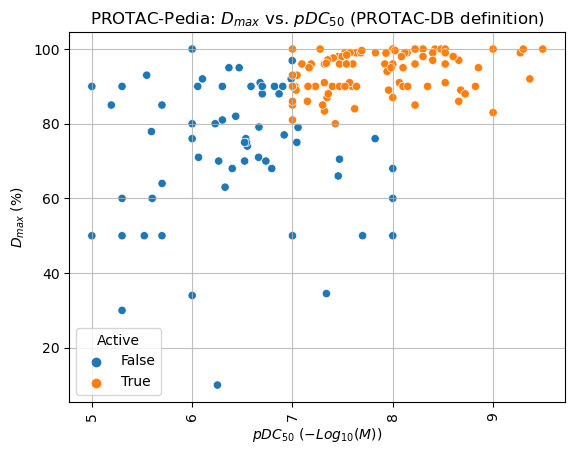

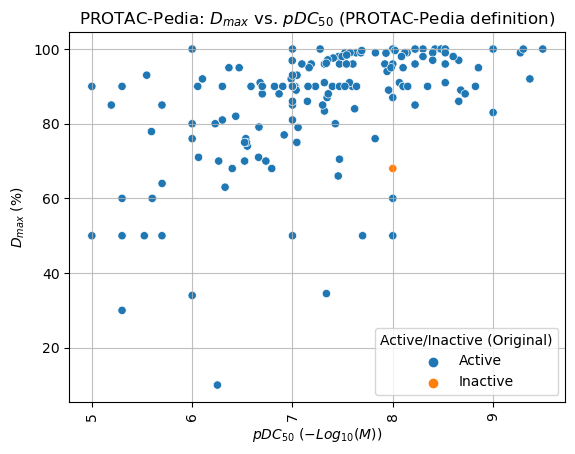

In [39]:
tmp = protac_pedia_df.copy().dropna(subset=['active'])
new_names = {
    'pDC50': '$pDC_{50}$ ($-Log_{10}(M)$)',
    'Dmax': '$D_{max}$ (%)',
    'active': 'Active',
}
tmp = tmp.rename(columns=new_names)
tmp['$pDC_{50}$'] = tmp['$pDC_{50}$ ($-Log_{10}(M)$)'].astype(float)
tmp['$D_{max}$ (%)'] = tmp['$D_{max}$ (%)'].astype(float) * 100

print(f'Num. active entries: {len(tmp[tmp["Active"] == True])}')
print(f'Num. inactive entries: {len(tmp[tmp["Active"] == False])}')

# _ = sns.scatterplot(data=tmp, x='$pDC_{50}$ ($-Log_{10}(M)$)', y='$D_{max}$ (%)', hue='Treatment Hours', palette='icefire')
_ = sns.scatterplot(data=tmp, x='$pDC_{50}$ ($-Log_{10}(M)$)', y='$D_{max}$ (%)', hue='Active')
plt.xticks(rotation=90)
plt.grid(axis='both', alpha=0.8)
plt.title('PROTAC-Pedia: $D_{max}$ vs. $pDC_{50}$ (PROTAC-DB definition)')
# plt.xscale('log')
# plt.savefig(os.path.join(data_dir, 'figures', 'Dmax_percentage_vs_DC50.pdf'))
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1), ncol=1) #, fancybox=True, shadow=True)
plt.show()


_ = sns.scatterplot(data=tmp, x='$pDC_{50}$ ($-Log_{10}(M)$)', y='$D_{max}$ (%)', hue='Active/Inactive (Original)')
plt.xticks(rotation=90)
plt.grid(axis='both', alpha=0.8)
plt.title('PROTAC-Pedia: $D_{max}$ vs. $pDC_{50}$ (PROTAC-Pedia definition)')
# plt.xscale('log')
# plt.savefig(os.path.join(data_dir, 'figures', 'Dmax_percentage_vs_DC50.pdf'))
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1), ncol=1) #, fancybox=True, shadow=True)
plt.show()

[]

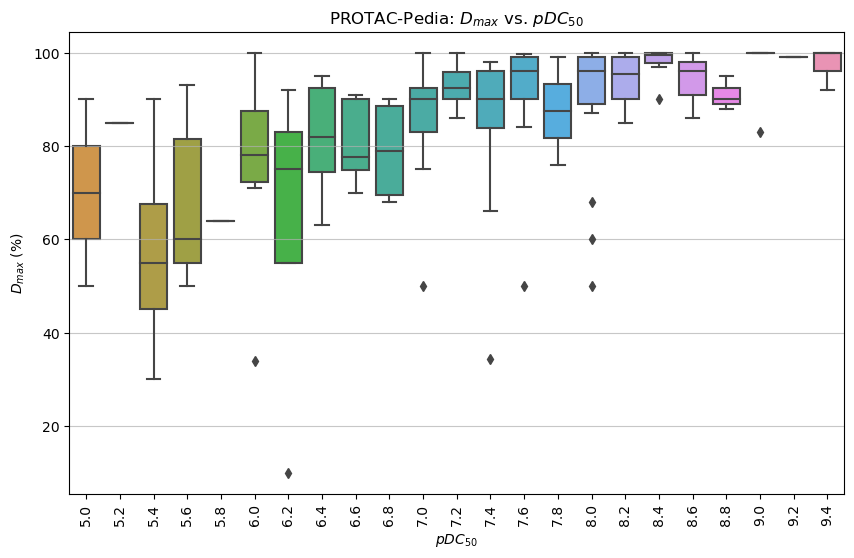

In [40]:
tmp['$D_{max}$ (%)'] = protac_pedia_df['Dmax'].astype(float) * 100
# Change the bin size by rounding
t = (tmp[['$pDC_{50}$', '$D_{max}$ (%)']] * 0.5).round(1) / 0.5
# Change plot/figure size
plt.figure(figsize=(10, 6))
sns.boxplot(data=t, x='$pDC_{50}$', y='$D_{max}$ (%)')
plt.xticks(rotation=90)
plt.grid(axis='y', alpha=0.7)
plt.title('PROTAC-Pedia: $D_{max}$ vs. $pDC_{50}$')
plt.plot()

[]

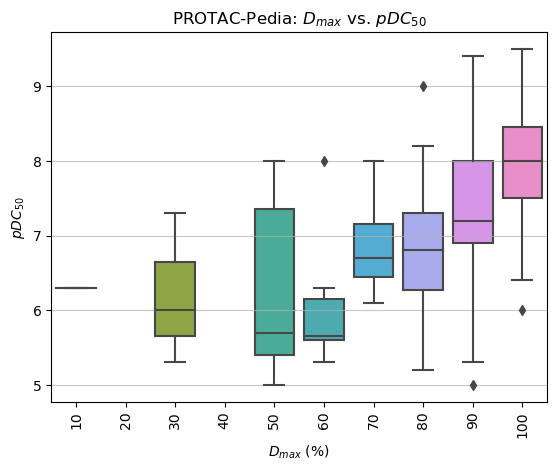

In [41]:
tmp['$D_{max}$ (%)'] = protac_pedia_df['Dmax'].astype(float)
tmp = tmp.dropna(subset=['$D_{max}$ (%)'])
# Change the bin size by rounding
t = (tmp[['$pDC_{50}$', '$D_{max}$ (%)']] * (1 / 1)).round(1) / (1 / 1)
t['$D_{max}$ (%)'] = (t['$D_{max}$ (%)'] * 100).astype(int)
_ = sns.boxplot(data=t, y='$pDC_{50}$', x='$D_{max}$ (%)')
plt.xticks(rotation=90)
plt.grid(axis='y', alpha=0.7)
plt.title('PROTAC-Pedia: $D_{max}$ vs. $pDC_{50}$')
plt.plot()

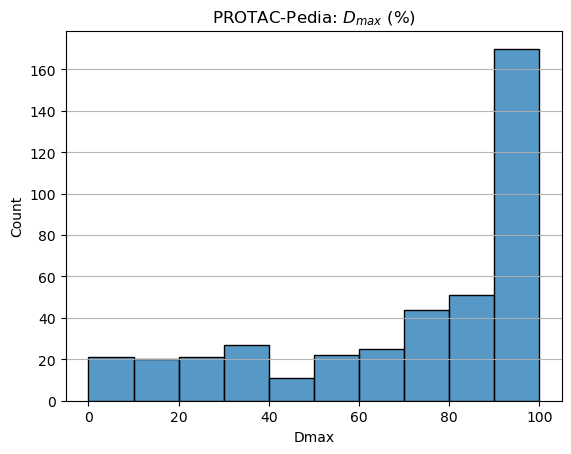

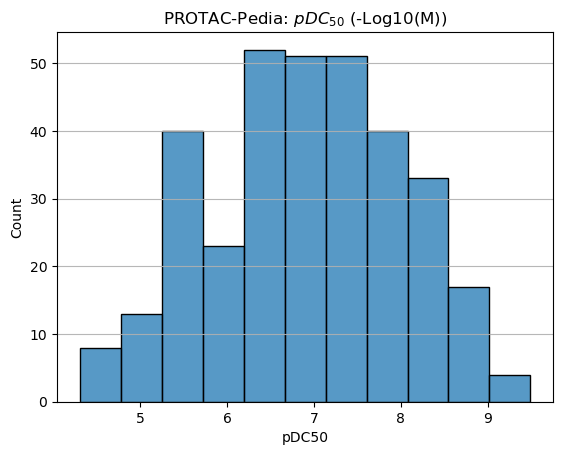

In [42]:
_ = sns.histplot(data=protac_pedia_df['Dmax'].astype(float) * 100)
# plt.xticks(rotation=90)
plt.grid(axis='y', alpha=0.9)
plt.title('PROTAC-Pedia: $D_{max}$ (%)')
plt.show()

_ = sns.histplot(data=protac_pedia_df['pDC50'])
# plt.xticks(rotation=90)
plt.grid(axis='y', alpha=0.9)
plt.title('PROTAC-Pedia: $pDC_{50}$ (-Log10(M))')
plt.show()

### E3 Ligase

#### Get Amino Acid Sequence

Assigning the gene ID to the E3 ligase entries:

In [43]:
print(protac_pedia_df['E3 Ligase'].unique())

['VHL' 'Cereblon' 'Iap' 'Mdm2' 'Ubr1' 'RNF4' 'RNF114' 'cIAP1']


In [44]:
e3ligase2genes = {
    'VHL': 'P40337',
    'CRBN': 'Q96SW2',
    'Cereblon': 'Q96SW2',
    'DCAF11': 'Q8TEB1',
    'DCAF15': 'Q66K64',
    'DCAF16': 'Q9NXF7',
    'MDM2': 'Q00987',
    'XIAP': 'P98170',
    'CIAP1': 'Q7Z460',
    'IAP': 'P98170', # I couldn't find the Uniprot ID for this one, so it's XIAP
    'AHR': 'P35869',
    'RNF4': 'P78317',
    'RNF114': 'Q9Y508',
    'FEM1B': 'Q9UK73',
    'UBR1': 'Q8IWV7',
}
protac_pedia_df['e3_ligase_gene'] = protac_pedia_df['E3 Ligase'].str.upper().map(e3ligase2genes)
protac_pedia_df['e3_ligase_gene']

0       P40337
1       P40337
2       P40337
3       P40337
4       P40337
         ...  
1198       NaN
1199       NaN
1200       NaN
1201       NaN
1202    P40337
Name: e3_ligase_gene, Length: 1203, dtype: object

In [45]:
import requests

def get_seq(uniprot_id: str, local_dict: dict) -> str:
    if pd.isna(uniprot_id):
        return None
    if ',' in uniprot_id:
        for u in uniprot_id.strip().split(','):
            if u in local_dict:
                return local_dict[u]
            else:
                ret = get_seq(u, local_dict)
                if ret is not None:
                    local_dict[u] = ret
        return None
    if uniprot_id in local_dict:
        return local_dict[uniprot_id]
    fasta_url = f'http://www.uniprot.org/uniprot/{uniprot_id}.fasta'
    try:
        response = requests.post(fasta_url)
        cData = ''.join(response.text)
        i = cData.index('\n') + 1
        seq = cData[i:].rstrip().replace('\n', '')
        # print(f'Getting {cData} from URL: {fasta_url}')
        return seq
    except:
        print(f'Error getting {uniprot_id} from URL: {fasta_url}')
        return None

In [46]:
e3_ligase_sequences_filepath = os.path.join(data_dir, 'processed', 'e3_ligase_sequences.pkl')
failed = False
if os.path.exists(e3_ligase_sequences_filepath):
    with open(e3_ligase_sequences_filepath, 'rb') as f:
        e3_seqs = pickle.load(f)
else:
    e3_seqs = {}

cID = list(set(protac_pedia_df['e3_ligase_gene'].tolist()))
for uniprot_id in cID:
    seq = get_seq(uniprot_id, e3_seqs)
    if seq is not None:
        e3_seqs[uniprot_id] = seq
    else:
        failed = True
if not failed:
    with open(e3_ligase_sequences_filepath, 'wb') as f:
        pickle.dump(e3_seqs, f)
# Add 'Unknown' sequences corresponding to 'Unknown' genes/POIs
e3_seqs['Unknown'] = 'Unknown'
print(e3_seqs.keys())

dict_keys(['P98170', 'P40337', 'P78317', 'Q9Y508', 'Q8IWV7', 'Q00987', 'Q7Z460', 'Unknown'])


In [47]:
protac_pedia_df['e3_ligase_seq'] = protac_pedia_df['e3_ligase_gene'].map(e3_seqs)
protac_pedia_df['e3_ligase_seq'].head()

0    MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPEELGAEEEMEAGRPRPVLRSVNSREPSQVIFCNRSPRVVLPVWLNFDGEPQ...
1    MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPEELGAEEEMEAGRPRPVLRSVNSREPSQVIFCNRSPRVVLPVWLNFDGEPQ...
2    MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPEELGAEEEMEAGRPRPVLRSVNSREPSQVIFCNRSPRVVLPVWLNFDGEPQ...
3    MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPEELGAEEEMEAGRPRPVLRSVNSREPSQVIFCNRSPRVVLPVWLNFDGEPQ...
4    MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPEELGAEEEMEAGRPRPVLRSVNSREPSQVIFCNRSPRVVLPVWLNFDGEPQ...
Name: e3_ligase_seq, dtype: object

#### Aggregating E3 Ligase Classes

column: E3 Ligase  (#unique: 8)
                  0    1    2     3      4     5       6     7
E3 Ligase  Cereblon  VHL  Iap  Mdm2  cIAP1  Ubr1  RNF114  RNF4
size            691  444   42    15      7     2       1     1 



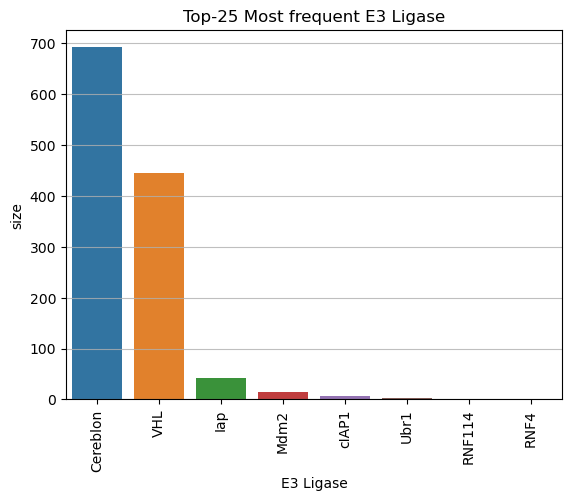

In [48]:
tmp = protac_pedia_df.groupby('E3 Ligase', as_index=False).size().sort_values('size', ascending=False, ignore_index=True)
print(f'column: E3 Ligase  (#unique: {tmp.shape[0]:,})')
print(tmp.head(20).T, '\n')
# Plotting
sns.barplot(data=tmp.head(25), x='E3 Ligase', y='size')
plt.xticks(rotation=90)
plt.grid(axis='y', alpha=0.8)
plt.title(f'Top-25 Most frequent E3 Ligase')
# plt.savefig(os.path.join(data_dir, 'figures', 'e3 Ligase_distribution.pdf'))
plt.show()

In [49]:
for i in range(len(protac_pedia_df['E3 Ligase'])):
    if 'IAP' in str(protac_pedia_df.at[i, 'E3 Ligase']).upper():
        protac_pedia_df.at[i, 'E3 Ligase'] = 'IAP'
    elif 'DCAF' in str(protac_pedia_df.at[i, 'E3 Ligase']):
        protac_pedia_df.at[i, 'E3 Ligase'] = 'DCAF'
    elif 'RNF' in str(protac_pedia_df.at[i, 'E3 Ligase']):
        protac_pedia_df.at[i, 'E3 Ligase'] = 'RNF'
protac_pedia_df['E3 Ligase'] = protac_pedia_df['E3 Ligase'].str.replace('Cereblon', 'CRBN')
protac_pedia_df['E3 Ligase'] = protac_pedia_df['E3 Ligase'].str.replace('Mdm2', 'MDM2')

### POI: Apply Gene Mutations

For consistency and comparison with PROTAC-DB, if sequences in PROTAC-Pedia are _not_ present in PROTAC-DB, we mark them as "Unknown":

In [50]:
poi_seq_protac_pedia_filepath = os.path.join(data_dir, 'processed', 'poi_sequences_protac_db_and_pedia.pkl')
poi_seq_protac_db_filepath = os.path.join(data_dir, 'processed', 'poi_sequences.pkl')

poi_seqs = {}
if os.path.exists(poi_seq_protac_pedia_filepath):
    with open(poi_seq_protac_pedia_filepath, 'rb') as f:
        poi_seqs.update(pickle.load(f))
if os.path.exists(poi_seq_protac_db_filepath):
    with open(poi_seq_protac_db_filepath, 'rb') as f:
        poi_seqs.update(pickle.load(f))


cID = list(set(protac_pedia_df['Target'].tolist()))
for uniprot_id in cID:
    seq = get_seq(uniprot_id, poi_seqs)
    if seq is not None:
        poi_seqs[uniprot_id] = seq
    else:
        failed = True
if not failed:
    with open(poi_seq_protac_db_filepath, 'wb') as f:
        pickle.dump(poi_seqs, f)
# Add 'Unknown' sequences corresponding to 'Unknown' genes/POIs
poi_seqs['Unknown'] = 'Unknown'
print(poi_seqs.keys())

Error getting Q07820 from URL: http://www.uniprot.org/uniprot/Q07820.fasta


NOTE! Some PROTAC-Pedia entries have multiple POI targets, we will only keep the first one:

We name the new column "Uniprot" for consistency with PROTAC-DB.

In [ ]:
print(f'Num. entries: {len(protac_pedia_df)}')
print(f'Num. entries with no target: {len(protac_pedia_df.dropna(subset=["Target"]))}')
protac_pedia_df = protac_pedia_df.dropna(subset=['Target'])

Num. entries: 1203
Num. entries with no target: 1203


In [ ]:
protac_pedia_df.loc[:, 'Uniprot'] = protac_pedia_df.apply(lambda row: row['Target'].replace(' ', '').split(',')[0], axis=1)

Finally, get the POI sequence from the fasta-scraped sequences:

In [ ]:
# protac_pedia_df['poi_seq'] = protac_pedia_df.apply(lambda row: seqs.get(row['Uniprot'], 'Unknown'), axis=1)
protac_pedia_df['poi_seq'] = protac_pedia_df['Uniprot'].map(poi_seqs)
print(len(protac_pedia_df))
print(len(protac_pedia_df[protac_pedia_df['poi_seq'] == 'Unknown']))

1203
0


Function for applying mutations:

In [ ]:
def apply_mutation(uniprot: str, gene: str, seq: str):
    if len(gene.split(' ')) == 1:
        return seq
    # TODO: Just use a dictionary and replace these sequences straightaway...
    exceptions = {
        ('O60885', 'BRD4 BD1'): poi_seqs['O60885'],
        ('P10275', 'AR-V7'): poi_seqs['P10275'],
        ('P00533', 'EGFR e19d'): poi_seqs['P10275'], # TODO: Not working... why???
    }
    if (uniprot, gene) in exceptions:
        return exceptions[(uniprot, gene)]
    else:
        mutation = gene.split(' ')[1]
        operations = mutation.split('/') if '/' in mutation else [mutation]
        del_ops = 0
        for op in operations:
            if 'del' in op.lower():
                idx = int(op.split('del')[1]) - 1
                print(f'Operation: {op} on ...{seq[idx-8:idx]}[{seq[idx]}]{seq[idx+1:idx+8]}...')
                seq = seq[:idx] + seq[idx + 1:]
                del_ops += 1
            else:
                # Replace aminoacid at a specific index
                # NOTE: The indexing starts from one, not zero.
                # NOTE: If a deletion has happened before, the index is still
                # relative to the whole sequence lenght (weird...)
                curr, idx, new = op[0].upper(), int(op[1:-1])-1, op[-1].upper()
                idx -= del_ops
                print(f'Operation: {op} on ...{seq[idx-8:idx]}[{seq[idx]} -> {new}]{seq[idx+1:idx+8]}...')
                assert curr == seq[idx], f'Replacement at position {idx} failed. Expected "{curr}", found: "{seq[idx]}"'
                seq = seq[:idx] + new + seq[idx + 1:]
        return seq

NOTE! There is no gene information in PROTAC-Pedia, so we cannot apply mutations to the POI sequences.

## Clean Cell Type

NOTE! Some PROTAC-Pedia entries have multiple cell types, we will only keep the first one:

In [ ]:
def get_cell_type(cell):
    if ',' in str(cell):
        divider = ','
    else:
        divider = ';'
    return str(cell).replace(' ', '').split(divider)[0].rstrip()

protac_pedia_df['cell_type'] = protac_pedia_df['Cells'].fillna('Unknown')
protac_pedia_df['cell_type'] = protac_pedia_df['Cells'].apply(lambda cell: get_cell_type(cell))
print(protac_pedia_df['cell_type'])

0       MOLT-4
1       MOLT-4
2       MOLT-4
3       MOLT-4
4       MOLT-4
         ...  
1198      A549
1199       nan
1200       nan
1201      A549
1202      Huh7
Name: cell_type, Length: 1203, dtype: object


## Save DB

Save curated PROTAC-Pedia to CSV:

In [ ]:
old2new = {
    'PROTAC SMILES_nostereo': 'Smiles_nostereo',
    'PROTAC SMILES': 'Smiles',
    'E3 Ligase': 'e3_ligase',
}
protac_pedia_df = protac_pedia_df.rename(columns=old2new)
protac_pedia_df['poi_gene_id'] = 'Unknown'

In [ ]:
# df_file = os.path.join(data_dir, 'processed', 'protac-pedia_DC50_Dmax.csv')
# protac_pedia_df.to_csv(df_file, index=False)
df_file = os.path.join(data_dir, 'processed', 'protac_pedia_dc50_dmax.csv')
protac_pedia_df.to_csv(df_file, index=False)

## Clean PROTACs Substructures

In [1]:
from IPython.display import display_html
# from IPython.core.interactiveshell import InteractiveShell
# InteractiveShell.ast_node_interactivity = 'all'

import collections
import itertools
import re
import gc
import math
import numpy as np
import pandas as pd
import pickle
import requests as r
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import os

import typing
from typing import Mapping, Literal, Callable, List, ClassVar, Any

from uuid import uuid4
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs, MACCSkeys
from datetime import date
from scipy.sparse import csr_matrix, vstack

import sklearn
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn import preprocessing
from sklearn import metrics
from sklearn.metrics import classification_report, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import class_weight

pd.set_option('display.max_columns', 1000, 'display.width', 2000, 'display.max_colwidth', 100)

In [2]:
data_dir = os.path.join(os.getcwd(), '..', 'data')
src_dir = os.path.join(os.getcwd(), '..', 'src')
fig_dir = os.path.join(data_dir, 'figures')
checkpoint_dir = os.path.join(os.getcwd(), '..', 'checkpoints')
dirs_to_make = [
    src_dir,
    data_dir,
    os.path.join(data_dir, 'processed'),
    os.path.join(data_dir, 'smiles_in_smiles_out'),
    os.path.join(data_dir, 'smiles_in_selfies_out'),
    os.path.join(data_dir, 'selfies_in_selfies_out'),
    
    os.path.join(data_dir, 'smiles_in_smiles_out_randorder'),
    os.path.join(data_dir, 'smiles_in_selfies_out_randorder'),
    os.path.join(data_dir, 'selfies_in_selfies_out_randorder'),
    
    # os.path.join(data_dir, 'raw'),
    # os.path.join(data_dir, 'train'),
    # os.path.join(data_dir, 'val'),
    # os.path.join(data_dir, 'test'),
    # fig_dir,
    # checkpoint_dir,
]
for d in dirs_to_make:
    if not os.path.exists(d):
        os.makedirs(d)

In [3]:
df_file = os.path.join(data_dir, 'raw', 'protac_pedia_20220210.csv')
protac_pedia_df = pd.read_csv(df_file)
print(protac_pedia_df.head())

   PROTACDB ID                                                                                        PROTAC SMILES Active/Inactive Best PROTAC   Cells     cLogP                              Comments        Curator   Dc50     Dmax                                                             E3 Binder SMILES E3 Ligase Ec50 of Ligand Cells Ec50 of PROTAC Cells               exit_vector  Hbond acceptors  Hbond donors Ic50 of Ligand Ic50 of PROTAC Ligand Name                                                                                        Ligand SMILES          Linker Linker Type  linker_ha  linker_no  linker_rb        MW    Off Targets Reported PATENT Ligand PDB Ligand ID      Pubmed  PROTAC Name Proteomics Data Available  Secondary Pubmed    Status  Target Tested A Non Binding E3 Control Tested Competition With Ligand Tested Engagement In Cells Tested Proteaseome Inhibitor Time    TPSA
0            1  Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CC(=O)N2CCN(CC[

Drop NaN and duplicates:

In [4]:
cols = ['PROTAC SMILES', 'E3 Binder SMILES', 'Linker', 'Ligand SMILES']
sub_df = protac_pedia_df.dropna(subset=cols)[cols].drop_duplicates()
old2new = {
    'Linker': 'Linker SMILES',
    'Ligand SMILES': 'POI Ligand SMILES',
}
sub_df = sub_df.rename(columns=old2new)
display(sub_df.head())

,PROTAC SMILES,E3 Binder SMILES,Linker SMILES,POI Ligand SMILES
0,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CC(=O)N2CCN(CC[C@H](CSc3ccccc...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...
1,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCC(=O)N2CCN(CC[C@H](CSc3cccc...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CCC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...
2,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCC(=O)N2CCN(CC[C@H](CSc3ccc...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CCCC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...
3,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCCC(=O)N2CCN(CC[C@H](CSc3cc...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CCCCC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...
4,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCCCC(=O)N2CCN(CC[C@H](CSc3c...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CCCCCC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...


Some entries have identical POI ligand and E3 binder, we remove them:

In [5]:
print(f'Before removal: {len(sub_df)}')
sub_df = sub_df[sub_df['POI Ligand SMILES'] != sub_df['E3 Binder SMILES']]
print(f'After removal: {len(sub_df)}')

Before removal: 1203
After removal: 1195


In [6]:
def canonize_smiles(smiles):
    return Chem.MolToSmiles(Chem.MolFromSmiles(smiles))

sub_df['Canonized PROTAC SMILES'] = sub_df['PROTAC SMILES'].apply(lambda x: canonize_smiles(x))

for row in sub_df.iterrows():
    row = row[1].to_dict()
    print('Original: ', row['PROTAC SMILES'])
    print('Canonized: ', row['Canonized PROTAC SMILES'])
    print('-' * 80)
    break

Original:  Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CC(=O)N2CCN(CC[C@H](CSc3ccccc3)Nc3ccc(S(=O)(=O)NC(=O)c4ccc(N5CCN(CC6=C(c7ccc(Cl)cc7)CCC(C)(C)C6)CC5)cc4)cc3S(=O)(=O)C(F)(F)F)CC2)C(C)(C)C)cc1
Canonized:  Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CC(=O)N2CCN(CC[C@H](CSc3ccccc3)Nc3ccc(S(=O)(=O)NC(=O)c4ccc(N5CCN(CC6=C(c7ccc(Cl)cc7)CCC(C)(C)C6)CC5)cc4)cc3S(=O)(=O)C(F)(F)F)CC2)C(C)(C)C)cc1
--------------------------------------------------------------------------------


In [7]:
from rdkit import DataStructs
from rdkit.Chem import AllChem

def get_tanimoto(smiles1, smiles2):
    mol1 = Chem.MolFromSmiles(smiles1)
    mol2 = Chem.MolFromSmiles(smiles2)
    fpgen = AllChem.GetRDKitFPGenerator()
    fp1 = fpgen.GetFingerprint(mol1)
    fp2 = fpgen.GetFingerprint(mol2)
    return DataStructs.TanimotoSimilarity(fp1, fp2)

print(get_tanimoto(sub_df['PROTAC SMILES'][0], sub_df['Linker SMILES'][0]))
print(get_tanimoto(sub_df['PROTAC SMILES'][0], sub_df['E3 Binder SMILES'][0]))
print(get_tanimoto(sub_df['PROTAC SMILES'][0], sub_df['POI Ligand SMILES'][0]))

0.016786570743405275
0.5881294964028777
0.817095038852361


Add SELFIES columns:

In [8]:
import selfies as sf

for smiles_col in sub_df.columns:
    if 'SMILES' not in smiles_col:
        continue
    selfies_col = smiles_col.replace('SMILES', 'SELFIES')
    try:
        sub_df[selfies_col] = sub_df[smiles_col].apply(sf.encoder)
    except sf.EncoderError:
        print('sf.encoder error!')
    except sf.DecoderError:
        print('sf.decoder error!')

outfile = os.path.join(data_dir, 'processed', 'processed_protac_pedia.csv')
sub_df.to_csv(outfile, index=False)
display(sub_df.head())

,PROTAC SMILES,E3 Binder SMILES,Linker SMILES,POI Ligand SMILES,Canonized PROTAC SMILES,PROTAC SELFIES,E3 Binder SELFIES,Linker SELFIES,POI Ligand SELFIES,Canonized PROTAC SELFIES
0,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CC(=O)N2CCN(CC[C@H](CSc3ccccc...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CC(=O)N2CCN(CC[C@H](CSc3ccccc...,[C][C][N][=C][S][C][Expl=Ring1][Branch1_1][C][=C][C][=C][Branch2_1][N][Branch1_1][C@Hexpl][Branc...,[C][C][N][=C][S][C][Expl=Ring1][Branch1_1][C][=C][C][=C][Branch2_1][Ring2][Ring2][C@Hexpl][Branc...,[N][C][Branch1_2][C][=O][C][C][=O],[C][C][Branch1_1][C][C][C][C][C][Branch1_1][N][C][=C][C][=C][Branch1_1][C][Cl][C][=C][Ring1][Bra...,[C][C][N][=C][S][C][Expl=Ring1][Branch1_1][C][=C][C][=C][Branch2_1][N][Branch1_1][C@Hexpl][Branc...
1,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCC(=O)N2CCN(CC[C@H](CSc3cccc...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CCC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCC(=O)N2CCN(CC[C@H](CSc3cccc...,[C][C][N][=C][S][C][Expl=Ring1][Branch1_1][C][=C][C][=C][Branch2_1][N][Branch1_2][C@Hexpl][Branc...,[C][C][N][=C][S][C][Expl=Ring1][Branch1_1][C][=C][C][=C][Branch2_1][Ring2][Ring2][C@Hexpl][Branc...,[N][C][Branch1_2][C][=O][C][C][C][=O],[C][C][Branch1_1][C][C][C][C][C][Branch1_1][N][C][=C][C][=C][Branch1_1][C][Cl][C][=C][Ring1][Bra...,[C][C][N][=C][S][C][Expl=Ring1][Branch1_1][C][=C][C][=C][Branch2_1][N][Branch1_2][C@Hexpl][Branc...
2,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCC(=O)N2CCN(CC[C@H](CSc3ccc...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CCCC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCC(=O)N2CCN(CC[C@H](CSc3ccc...,[C][C][N][=C][S][C][Expl=Ring1][Branch1_1][C][=C][C][=C][Branch2_1][N][Branch1_3][C@Hexpl][Branc...,[C][C][N][=C][S][C][Expl=Ring1][Branch1_1][C][=C][C][=C][Branch2_1][Ring2][Ring2][C@Hexpl][Branc...,[N][C][Branch1_2][C][=O][C][C][C][C][=O],[C][C][Branch1_1][C][C][C][C][C][Branch1_1][N][C][=C][C][=C][Branch1_1][C][Cl][C][=C][Ring1][Bra...,[C][C][N][=C][S][C][Expl=Ring1][Branch1_1][C][=C][C][=C][Branch2_1][N][Branch1_3][C@Hexpl][Branc...
3,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCCC(=O)N2CCN(CC[C@H](CSc3cc...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CCCCC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCCC(=O)N2CCN(CC[C@H](CSc3cc...,[C][C][N][=C][S][C][Expl=Ring1][Branch1_1][C][=C][C][=C][Branch2_1][N][Branch2_1][C@Hexpl][Branc...,[C][C][N][=C][S][C][Expl=Ring1][Branch1_1][C][=C][C][=C][Branch2_1][Ring2][Ring2][C@Hexpl][Branc...,[N][C][Branch1_2][C][=O][C][C][C][C][C][=O],[C][C][Branch1_1][C][C][C][C][C][Branch1_1][N][C][=C][C][=C][Branch1_1][C][Cl][C][=C][Ring1][Bra...,[C][C][N][=C][S][C][Expl=Ring1][Branch1_1][C][=C][C][=C][Branch2_1][N][Branch2_1][C@Hexpl][Branc...
4,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCCCC(=O)N2CCN(CC[C@H](CSc3c...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CCCCCC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCCCC(=O)N2CCN(CC[C@H](CSc3c...,[C][C][N][=C][S][C][Expl=Ring1][Branch1_1][C][=C][C][=C][Branch2_1][N][Branch2_2][C@Hexpl][Branc...,[C][C][

In [9]:
cols = ['PROTAC SELFIES', 'E3 Binder SELFIES', 'Linker SELFIES', 'POI Ligand SELFIES']
sub_df = sub_df.dropna(subset=cols).drop_duplicates()
sub_df

,PROTAC SMILES,E3 Binder SMILES,Linker SMILES,POI Ligand SMILES,Canonized PROTAC SMILES,PROTAC SELFIES,E3 Binder SELFIES,Linker SELFIES,POI Ligand SELFIES,Canonized PROTAC SELFIES
0,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CC(=O)N2CCN(CC[C@H](CSc3ccccc...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CC(=O)N2CCN(CC[C@H](CSc3ccccc...,[C][C][N][=C][S][C][Expl=Ring1][Branch1_1][C][=C][C][=C][Branch2_1][N][Branch1_1][C@Hexpl][Branc...,[C][C][N][=C][S][C][Expl=Ring1][Branch1_1][C][=C][C][=C][Branch2_1][Ring2][Ring2][C@Hexpl][Branc...,[N][C][Branch1_2][C][=O][C][C][=O],[C][C][Branch1_1][C][C][C][C][C][Branch1_1][N][C][=C][C][=C][Branch1_1][C][Cl][C][=C][Ring1][Bra...,[C][C][N][=C][S][C][Expl=Ring1][Branch1_1][C][=C][C][=C][Branch2_1][N][Branch1_1][C@Hexpl][Branc...
1,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCC(=O)N2CCN(CC[C@H](CSc3cccc...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CCC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCC(=O)N2CCN(CC[C@H](CSc3cccc...,[C][C][N][=C][S][C][Expl=Ring1][Branch1_1][C][=C][C][=C][Branch2_1][N][Branch1_2][C@Hexpl][Branc...,[C][C][N][=C][S][C][Expl=Ring1][Branch1_1][C][=C][C][=C][Branch2_1][Ring2][Ring2][C@Hexpl][Branc...,[N][C][Branch1_2][C][=O][C][C][C][=O],[C][C][Branch1_1][C][C][C][C][C][Branch1_1][N][C][=C][C][=C][Branch1_1][C][Cl][C][=C][Ring1][Bra...,[C][C][N][=C][S][C][Expl=Ring1][Branch1_1][C][=C][C][=C][Branch2_1][N][Branch1_2][C@Hexpl][Branc...
2,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCC(=O)N2CCN(CC[C@H](CSc3ccc...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CCCC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCC(=O)N2CCN(CC[C@H](CSc3ccc...,[C][C][N][=C][S][C][Expl=Ring1][Branch1_1][C][=C][C][=C][Branch2_1][N][Branch1_3][C@Hexpl][Branc...,[C][C][N][=C][S][C][Expl=Ring1][Branch1_1][C][=C][C][=C][Branch2_1][Ring2][Ring2][C@Hexpl][Branc...,[N][C][Branch1_2][C][=O][C][C][C][C][=O],[C][C][Branch1_1][C][C][C][C][C][Branch1_1][N][C][=C][C][=C][Branch1_1][C][Cl][C][=C][Ring1][Bra...,[C][C][N][=C][S][C][Expl=Ring1][Branch1_1][C][=C][C][=C][Branch2_1][N][Branch1_3][C@Hexpl][Branc...
3,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCCC(=O)N2CCN(CC[C@H](CSc3cc...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CCCCC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCCC(=O)N2CCN(CC[C@H](CSc3cc...,[C][C][N][=C][S][C][Expl=Ring1][Branch1_1][C][=C][C][=C][Branch2_1][N][Branch2_1][C@Hexpl][Branc...,[C][C][N][=C][S][C][Expl=Ring1][Branch1_1][C][=C][C][=C][Branch2_1][Ring2][Ring2][C@Hexpl][Branc...,[N][C][Branch1_2][C][=O][C][C][C][C][C][=O],[C][C][Branch1_1][C][C][C][C][C][Branch1_1][N][C][=C][C][=C][Branch1_1][C][Cl][C][=C][Ring1][Bra...,[C][C][N][=C][S][C][Expl=Ring1][Branch1_1][C][=C][C][=C][Branch2_1][N][Branch2_1][C@Hexpl][Branc...
4,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCCCC(=O)N2CCN(CC[C@H](CSc3c...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CCCCCC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCCCC(=O)N2CCN(CC[C@H](CSc3c...,[C][C][N][=C][S][C][Expl=Ring1][Branch1_1][C][=C][C][=C][Branch2_1][N][Branch2_2][C@Hexpl][Branc...,[C][C][

PROTAC SMILES include the POI ligand, linker and E3 binder, but sometimes they start with either the POI ligand or the E3 binder.
In order to "ease" the generation, we put the labels in the order of the most similar...

In [10]:
def count_different_letters(string1, string2):
    count = 0
    for char1, char2 in zip(string1, string2):
        if char1 != char2:
            count += 1
    return count / min(len(string1), len(string2))


def get_order(protac_smiles, e3_smiles, linker_smiles, poi_smiles):
    """
    Returns the guessed order of the sub-molecules within a PROTAC SMILES.
    """
    half_protac = protac_smiles[:len(protac_smiles) // 2]
    e3_diff = count_different_letters(half_protac, e3_smiles)
    linker_diff = count_different_letters(half_protac, linker_smiles)
    poi_diff = count_different_letters(half_protac, poi_smiles)
    min_diff = min(e3_diff, linker_diff, poi_diff)
    if min_diff == e3_diff:
        return ['E3 Binder ', 'Linker ', 'POI Ligand ']
    elif min_diff == linker_diff:
        # NOTE: This is a guess, as the linker is never the first sub-molecule.
        # return ['Linker ', 'E3 Binder ', 'POI ligand ']
        return ['POI Ligand ', 'E3 Binder ', 'Linker ']
    elif min_diff == poi_diff:
        return ['POI Ligand ', 'E3 Binder ', 'Linker ']
    else:
        return ['POI Ligand ', 'E3 Binder ', 'Linker ']


# Iterate over sub_df rows
for i, row in enumerate(sub_df.iterrows()):
    # Get the row as a dict
    row_dict = row[1].to_dict()
    protac_smiles = row_dict['PROTAC SMILES']
    poi_smiles = row_dict['POI Ligand SMILES']
    linker_smiles = row_dict['Linker SMILES']
    e3_smiles = row_dict['E3 Binder SMILES']
    print('       ', protac_smiles)
    print('')
    print('POI:   ', poi_smiles)
    print('Linker:', linker_smiles)
    print('E3:    ', e3_smiles)
    print('')
    print(f'Order: {get_order(protac_smiles, e3_smiles, linker_smiles, poi_smiles)}')
    print('-' * 80)
    if i > 5:
        break

        Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CC(=O)N2CCN(CC[C@H](CSc3ccccc3)Nc3ccc(S(=O)(=O)NC(=O)c4ccc(N5CCN(CC6=C(c7ccc(Cl)cc7)CCC(C)(C)C6)CC5)cc4)cc3S(=O)(=O)C(F)(F)F)CC2)C(C)(C)C)cc1

POI:    CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)(=O)C(F)(F)F)c4)cc3)CC2)C1
Linker: NC(=O)CC=O
E3:     Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1

Order: ['E3 Binder ', 'Linker ', 'POI Ligand ']
--------------------------------------------------------------------------------
        Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCC(=O)N2CCN(CC[C@H](CSc3ccccc3)Nc3ccc(S(=O)(=O)NC(=O)c4ccc(N5CCN(CC6=C(c7ccc(Cl)cc7)CCC(C)(C)C6)CC5)cc4)cc3S(=O)(=O)C(F)(F)F)CC2)C(C)(C)C)cc1

POI:    CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)(=O)C(F)(F)F)c4)cc3)CC2)C1
Linker: NC(=O)CCC=O
E3:     Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@

Function to generate the columns `text` and `labels`:

In [26]:
def set_text_and_labels(row, stype_in='SMILES', stype_out='SMILES'):
    row['text'] = row[f'PROTAC {stype_in}']
    substructures_ordered = get_order(
        row[f'PROTAC SMILES'],
        row[f'E3 Binder SMILES'],
        row[f'Linker SMILES'],
        row[f'POI Ligand SMILES'],
    )
    cols = [s + stype_out for s in substructures_ordered]
    row['labels'] = (
        row[f'{cols[1]}'] + '.' +
        row[f'{cols[0]}'] + '.' +
        row[f'{cols[2]}']
    )
    return row

set_text_and_labels(sub_df.iloc[0], stype_in='SMILES', stype_out='SMILES')

PROTAC SMILES               Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CC(=O)N2CCN(CC[C@H](CSc3ccccc...
E3 Binder SMILES                                    Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1
Linker SMILES                                                                                                        NC(=O)CC=O
POI Ligand SMILES           CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...
Canonized PROTAC SMILES     Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CC(=O)N2CCN(CC[C@H](CSc3ccccc...
PROTAC SELFIES              [C][C][N][=C][S][C][Expl=Ring1][Branch1_1][C][=C][C][=C][Branch2_1][N][Branch1_1][C@Hexpl][Branc...
E3 Binder SELFIES           [C][C][N][=C][S][C][Expl=Ring1][Branch1_1][C][=C][C][=C][Branch2_1][Ring2][Ring2][C@Hexpl][Branc...
Linker SELFIES                                                                               [N][C][Bran

Function to shuffle the sub-structures order in the labels. For instance: PROTAC with POI-Linker-E3 associated to PROTAC with E3-Linker-POI.

In [27]:
from functools import partial
import random

def randomize_labels_order(row, stype='SELFIES'):
    cols = [f'E3 Binder {stype}', f'Linker {stype}', f'POI Ligand {stype}']
    random.shuffle(cols)
    row['labels'] = '.'.join(row[cols])
    return row

row = set_text_and_labels(sub_df.iloc[0], stype_in='SMILES', stype_out='SMILES')
randomize_labels_order(row, stype='SMILES')

PROTAC SMILES               Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CC(=O)N2CCN(CC[C@H](CSc3ccccc...
E3 Binder SMILES                                    Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1
Linker SMILES                                                                                                        NC(=O)CC=O
POI Ligand SMILES           CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...
Canonized PROTAC SMILES     Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CC(=O)N2CCN(CC[C@H](CSc3ccccc...
PROTAC SELFIES              [C][C][N][=C][S][C][Expl=Ring1][Branch1_1][C][=C][C][=C][Branch2_1][N][Branch1_1][C@Hexpl][Branc...
E3 Binder SELFIES           [C][C][N][=C][S][C][Expl=Ring1][Branch1_1][C][=C][C][=C][Branch2_1][Ring2][Ring2][C@Hexpl][Branc...
Linker SELFIES                                                                               [N][C][Bran

Function for augmenting training data by randomizing SMILES strings (and their SELFIES):

In [32]:

import random

random.seed(42)

def randomize_smiles(smiles, num_smiles=5):
    mol = Chem.MolFromSmiles(smiles)
    try:
        rand_smiles = Chem.rdmolfiles.MolToRandomSmilesVect(
            mol,
            num_smiles,
            randomSeed=42,
            isomericSmiles=True,
            kekuleSmiles=False,
            allBondsExplicit=False,
            allHsExplicit=False,
        )
    except:
        return smiles
    return random.choice(rand_smiles)

def randomize_selfies(smiles, num_smiles=5):
    random_smiles = randomize_smiles(smiles, num_smiles)
    try:
        selfies = sf.encoder(random_smiles)
    except:
        selfies = sf.encoder(smiles)
    return selfies

def randomize_mol_str(mol_str, stype='SELFIES', num_smiles=5):
    if stype == 'SELFIES':
        return randomize_selfies(mol_str, num_smiles)
    elif stype == 'SMILES':
        return randomize_smiles(mol_str, num_smiles)
    else:
        raise ValueError(f'Unknown stype: {stype}. Allowed: "SELFIES", "SMILES".')

def randomize_labels_smiles(row, stype='SELFIES'):
    cols = [f'E3 Binder {stype}', f'Linker {stype}', f'POI Ligand {stype}']
    for col in cols:
        row[col] = randomize_mol_str(row[col], stype, num_smiles=1)
    row['labels'] = '.'.join(row[cols])
    return row

def randomize_text_smiles(row, stype='SELFIES'):
    rand_mol = randomize_mol_str(row[f'PROTAC {stype}'], stype, num_smiles=1)
    row[f'PROTAC {stype}'] = rand_mol
    return row

row = set_text_and_labels(sub_df.iloc[0], stype_in='SMILES', stype_out='SMILES')
print('randomize_text_smiles:\n', randomize_text_smiles(row, stype='SMILES'), '\n')
print('randomize_labels_smiles:\n', randomize_labels_smiles(row, stype='SMILES'), '\n')

# augmented_rows = train_df.sample(frac=0.3, random_state=42)
#
# for smiles_col in augmented_rows.columns:
#     if 'SMILES' not in smiles_col:
#         continue
#     selfies_col = smiles_col.replace('SMILES', 'SELFIES')
#     augmented_rows[selfies_col] = augmented_rows[smiles_col].apply(randomize_selfies)
#
# augmented_rows['labels'] = (
#     augmented_rows['E3 Binder SELFIES'] + '.' +
#     augmented_rows['Linker SELFIES'] + '.' +
#     augmented_rows['POI Ligand SELFIES']
# )
# augmented_rows['text'] = augmented_rows['PROTAC SELFIES']
# display(augmented_rows['text'])

randomize_text_smiles:
 PROTAC SMILES               c1([C@@H](NC([C@@H]2C[C@H](CN2C([C@@H](NC(CC(N2CCN(CC[C@H](CSc3ccccc3)Nc3ccc(cc3S(=O)(C(F)(F)F)=...
E3 Binder SMILES                                    Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1
Linker SMILES                                                                                                        NC(=O)CC=O
POI Ligand SMILES           CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...
Canonized PROTAC SMILES     Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CC(=O)N2CCN(CC[C@H](CSc3ccccc...
PROTAC SELFIES              [C][C][N][=C][S][C][Expl=Ring1][Branch1_1][C][=C][C][=C][Branch2_1][N][Branch1_1][C@Hexpl][Branc...
E3 Binder SELFIES           [C][C][N][=C][S][C][Expl=Ring1][Branch1_1][C][=C][C][=C][Branch2_1][Ring2][Ring2][C@Hexpl][Branc...
Linker SELFIES                                                                  

Apply augmentations and save dataframes accordingly:

In [46]:
from sklearn.model_selection import GroupShuffleSplit
import random

random.seed(42)

def save_df(df, phase, stype_in='SMILES', stype_out='SMILES', random_smiles_frac=0.3, random_order_frac=0.3, base_dir=data_dir):
    df_w_txt_n_labels = df.apply(partial(set_text_and_labels, stype_in=stype_in, stype_out=stype_out), axis=1)
    original_len = len(df)
    # Augment data accordingly
    if phase == 'train':
        df_w_augmentations = df_w_txt_n_labels.copy()
        if random_order_frac > 0:
            augmented = df_w_txt_n_labels.sample(frac=random_order_frac, random_state=42)
            augmented = augmented.apply(partial(randomize_labels_order, stype=stype_out), axis=1)
            df_w_augmentations = pd.concat([
                df_w_augmentations[['text', 'labels']],
                augmented[['text', 'labels']],
            ], axis=0)
        if random_smiles_frac > 0:
            augmented = df_w_txt_n_labels.sample(frac=random_smiles_frac, random_state=42)
            augmented = augmented.apply(partial(randomize_text_smiles, stype=stype_in), axis=1)
            augmented = augmented.apply(partial(randomize_labels_smiles, stype=stype_out), axis=1)
            df_w_augmentations = pd.concat([
                df_w_augmentations[['text', 'labels']],
                augmented[['text', 'labels']],
            ], axis=0)
        outfile = os.path.join(base_dir, f'train.csv')
        df_w_augmentations.to_csv(outfile, index=False)
        print(f'Original vs. augmented train size: {original_len} / {len(df_w_augmentations)}')
    else:
        outfile = os.path.join(base_dir, f'val.csv')
        df_w_txt_n_labels[['text', 'labels']].to_csv(outfile, index=False)
        print(f'Val size: {len(df_w_txt_n_labels)}')


# Split train and validation sets:
X = sub_df.drop(columns=['Canonized PROTAC SMILES'])
y = sub_df['Canonized PROTAC SMILES']
groups = sub_df['Canonized PROTAC SMILES']

for split_ratio in [0.8, 0.9, 0.95, 0.99]:
    gss = GroupShuffleSplit(n_splits=1, train_size=split_ratio, random_state=42)
    train_idx, val_idx = next(gss.split(X, y, groups))

    train_df = sub_df.iloc[train_idx]
    val_df = sub_df.iloc[val_idx]
    
    for random_smiles_frac in [0, 0.3]:
        for random_order_frac in [0, 0.3]:
            print(f'split ratio: {split_ratio}')
            print(f'random_smiles_frac: {random_smiles_frac}')
            print(f'random_order_frac: {random_order_frac}')
            print('len(train_df):', len(train_df))
            print('len(val_df):', len(val_df))
            # print('train_df:', train_df.head())
            # print('val_df:', val_df.head())
            print('num conflicts:', len(train_df[train_df['Canonized PROTAC SMILES'].isin(val_df['Canonized PROTAC SMILES'])]))
            print(f'-' * 80)
            for df, phase in [(train_df, 'train'), (val_df, 'val')]:
                # Setup directory name
                split_ratio_str = f'{int(split_ratio * 100)}-{int((1 - split_ratio) * 100)}-split'
                dir_name = f'protac_splitter_{split_ratio_str}_smiles_in_smiles_out'
                augmented_id = ''
                if random_order_frac > 0:
                    dir_name += f'_shuffled-labels-order-{random_order_frac:.0%}'
                if random_smiles_frac > 0:
                    dir_name += f'_random-labels-smiles-{random_smiles_frac:.0%}'
                if not os.path.exists(os.path.join(data_dir, 'final', dir_name)):
                    os.makedirs(os.path.join(data_dir, 'final', dir_name))
                save_df(
                    df,
                    phase,
                    stype_in='SMILES',
                    stype_out='SMILES',
                    random_smiles_frac=random_smiles_frac,
                    random_order_frac=random_order_frac,
                    base_dir=os.path.join(data_dir, 'final', dir_name),
                )
                # TODO: The SELFIES are breaking when trying to convert randomized SMILES...
                # save_df(
                #     df,
                #     phase,
                #     stype_in='SMILES',
                #     stype_out='SELFIES',
                #     random_smiles_frac=random_smiles_frac,
                #     random_order_frac=random_order_frac,
                #     base_dir=os.path.join(data_dir, 'protac_splitter'),
                # )
                # save_df(
                #     df,
                #     phase,
                #     stype_in='SELFIES',
                #     stype_out='SELFIES',
                #     random_smiles_frac=random_smiles_frac,
                #     random_order_frac=random_order_frac,
                #     base_dir=os.path.join(data_dir, 'protac_splitter'),
                # )

split ratio: 0.8
random_smiles_frac: 0
random_order_frac: 0
len(train_df): 935
len(val_df): 236
num conflicts: 0
--------------------------------------------------------------------------------
Original vs. augmented train size: 935 / 935
Val size: 236
split ratio: 0.8
random_smiles_frac: 0
random_order_frac: 0.3
len(train_df): 935
len(val_df): 236
num conflicts: 0
--------------------------------------------------------------------------------
Original vs. augmented train size: 935 / 1215
Val size: 236
split ratio: 0.8
random_smiles_frac: 0.3
random_order_frac: 0
len(train_df): 935
len(val_df): 236
num conflicts: 0
--------------------------------------------------------------------------------


[16:37:59] non-ring atom 8 marked aromatic


Original vs. augmented train size: 935 / 1215
Val size: 236
split ratio: 0.8
random_smiles_frac: 0.3
random_order_frac: 0.3
len(train_df): 935
len(val_df): 236
num conflicts: 0
--------------------------------------------------------------------------------


[16:38:01] non-ring atom 8 marked aromatic


Original vs. augmented train size: 935 / 1495
Val size: 236
split ratio: 0.9
random_smiles_frac: 0
random_order_frac: 0
len(train_df): 1053
len(val_df): 118
num conflicts: 0
--------------------------------------------------------------------------------
Original vs. augmented train size: 1053 / 1053
Val size: 118
split ratio: 0.9
random_smiles_frac: 0
random_order_frac: 0.3
len(train_df): 1053
len(val_df): 118
num conflicts: 0
--------------------------------------------------------------------------------
Original vs. augmented train size: 1053 / 1369
Val size: 118
split ratio: 0.9
random_smiles_frac: 0.3
random_order_frac: 0
len(train_df): 1053
len(val_df): 118
num conflicts: 0
--------------------------------------------------------------------------------
Original vs. augmented train size: 1053 / 1369
Val size: 118
split ratio: 0.9
random_smiles_frac: 0.3
random_order_frac: 0.3
len(train_df): 1053
len(val_df): 118
num conflicts: 0
--------------------------------------------------

[16:38:19] non-ring atom 5 marked aromatic
[16:38:19] non-ring atom 14 marked aromatic


Original vs. augmented train size: 1158 / 1505
Val size: 13
split ratio: 0.99
random_smiles_frac: 0.3
random_order_frac: 0.3
len(train_df): 1158
len(val_df): 13
num conflicts: 0
--------------------------------------------------------------------------------


[16:38:21] non-ring atom 5 marked aromatic
[16:38:22] non-ring atom 14 marked aromatic


Original vs. augmented train size: 1158 / 1852
Val size: 13


In [ ]:
def get_token_classes(protac_tokens, linker_tokens):
    token_classes = []
    linker_start = 0

    for i in range(len(protac_tokens)):
        if protac_tokens[i:i+len(linker_tokens)] == linker_tokens:
            token_classes.append('B-Linker')
            for j in range(1, len(linker_tokens)):
                token_classes.append('I-Linker')
            token_classes.append('E-Linker')
            linker_start = i + len(linker_tokens) - 1
        else:
            if i <= linker_start:
                token_classes.append('0')
            else:
                token_classes.append('O')

    return token_classes

protac_tokens = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I']
linker_tokens = ['D', 'E', 'F']

token_classes = get_token_classes(protac_tokens, linker_tokens)
print(token_classes)

['0', 'O', 'O', 'B-Linker', 'I-Linker', 'I-Linker', 'E-Linker', '0', '0', 'O', 'O', 'O']
